<a href="https://colab.research.google.com/github/HanifFaishalH/PCVK25_3F_15/blob/master/Week3_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama  : Hanif Faishal Hilmi

NIM   : 2341720116

Kelas : TI-3F

# Praktikum D1

Memberikan akses ke google drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Melakukan transformasi linier brightness

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 50


/tmp/ipython-input-4112814772.py:19: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


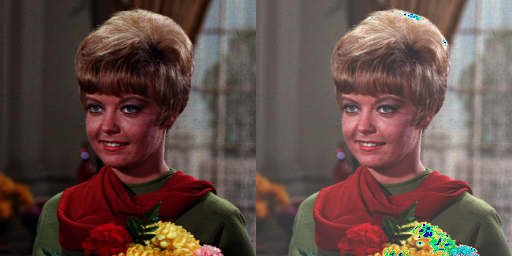

In [2]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')

try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

original = cv2.imread('/content/drive/MyDrive/PCVK25_3F_15/image/Gambar Jobsheet 3/female.tiff')
brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv2.hconcat((original, brightness_image))
cv2_imshow(final_frame)

# Tugas Praktikum D1

1. Implementasikan inverse citra pada Google Colaboratory menggunakan formula yang
terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:
*Gunakan Gambar KTM

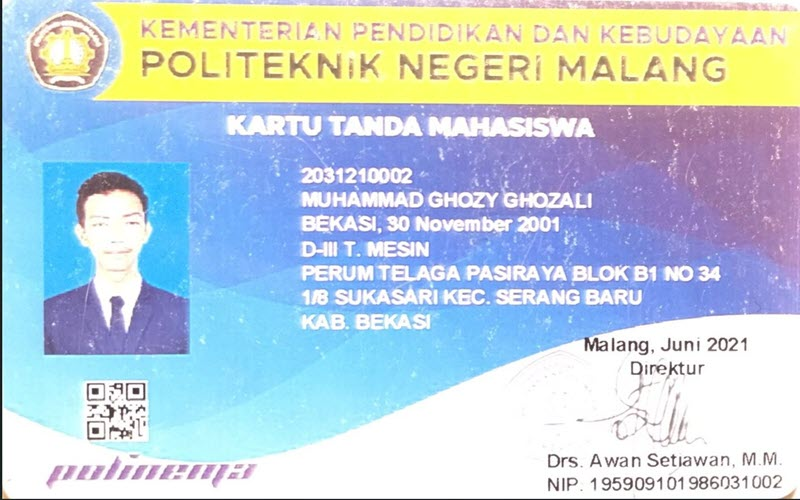

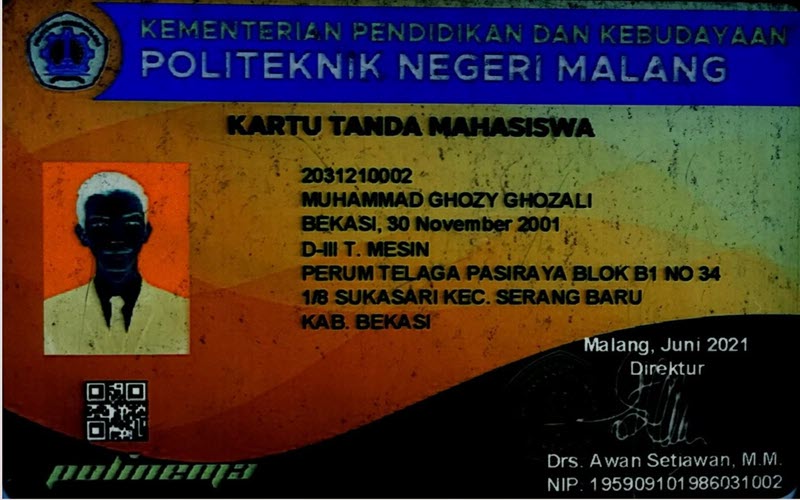

In [3]:
ktm = cv2.imread('/content/drive/MyDrive/PCVK25_3F_15/image/Gambar Jobsheet 3/KTM lama.jpg')

# melakukan inverse
ktm_inverse = 255 - ktm

# menampilkan hasil
cv2_imshow(ktm)
cv2_imshow(ktm_inverse)

2. Implementasikan transformasi contrast pada Google Colaboratory menggunakan
formula yang terdapat pada bagian Ulasan Teori untuk kontras, sehingga
menghasilkan keluaran seperti berikut:

 Mengubah tingkat kecerahan citra dan contrast
----------------------------------
Masukkan nilai kecerahan [-255 - 255]: 50
Masukkan nilai kontras [1.0 - 3.0]: 2


/tmp/ipython-input-1391770221.py:20: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


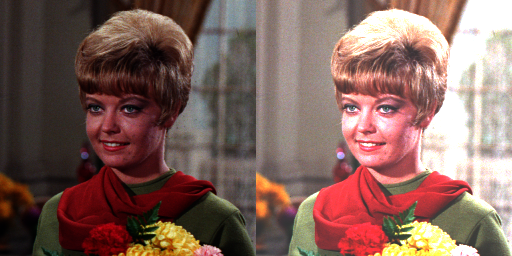

In [4]:

print(' Mengubah tingkat kecerahan citra dan contrast')
print('----------------------------------')

try:
  brightness = int(input('Masukkan nilai kecerahan [-255 - 255]: '))
  contrast = float(input('Masukkan nilai kontras [1.0 - 3.0]: '))
except ValueError:
  print('Error, not a number')

original = cv2.imread('/content/drive/MyDrive/PCVK25_3F_15/image/Gambar Jobsheet 3/female.tiff')
# Konversi ke float agar aman dihitung
original_float = original.astype(np.float32)

brightness_image = np.zeros(original.shape, original.dtype)
contrast_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)
      contrast_image[y,x,c] = np.clip(contrast * (original_float[y,x,c]) + brightness, 0, 255)

final_frame = cv2.hconcat((original, contrast_image))
cv2_imshow(final_frame)

3. Implementasikan transformasi logarithmic brightness pada Google Colaboratory
menggunakan formula yang terdapat pada bagian Ulasan Teori untuk transformasi
log, sehingga menghasilkan keluaran seperti berikut:

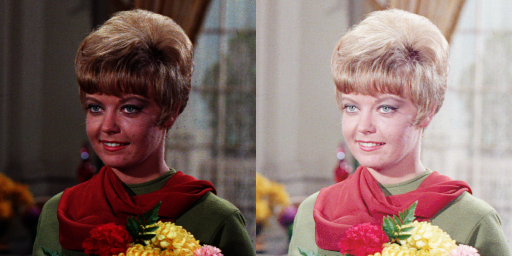

In [5]:
c = 255 / np.log(1 + np.max(original))

log_transform = c * (np.log(original + 1))

log_transform = np.array(log_transform, dtype = np.uint8)

final_frame = cv2.hconcat((original, log_transform))
cv2_imshow(final_frame)


4. Implementasikan transformasi grayscale menggunakan metode averaging, lightness,
dan luminance pada Google Colaboratory menggunakan formula yang terdapat pada
bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:


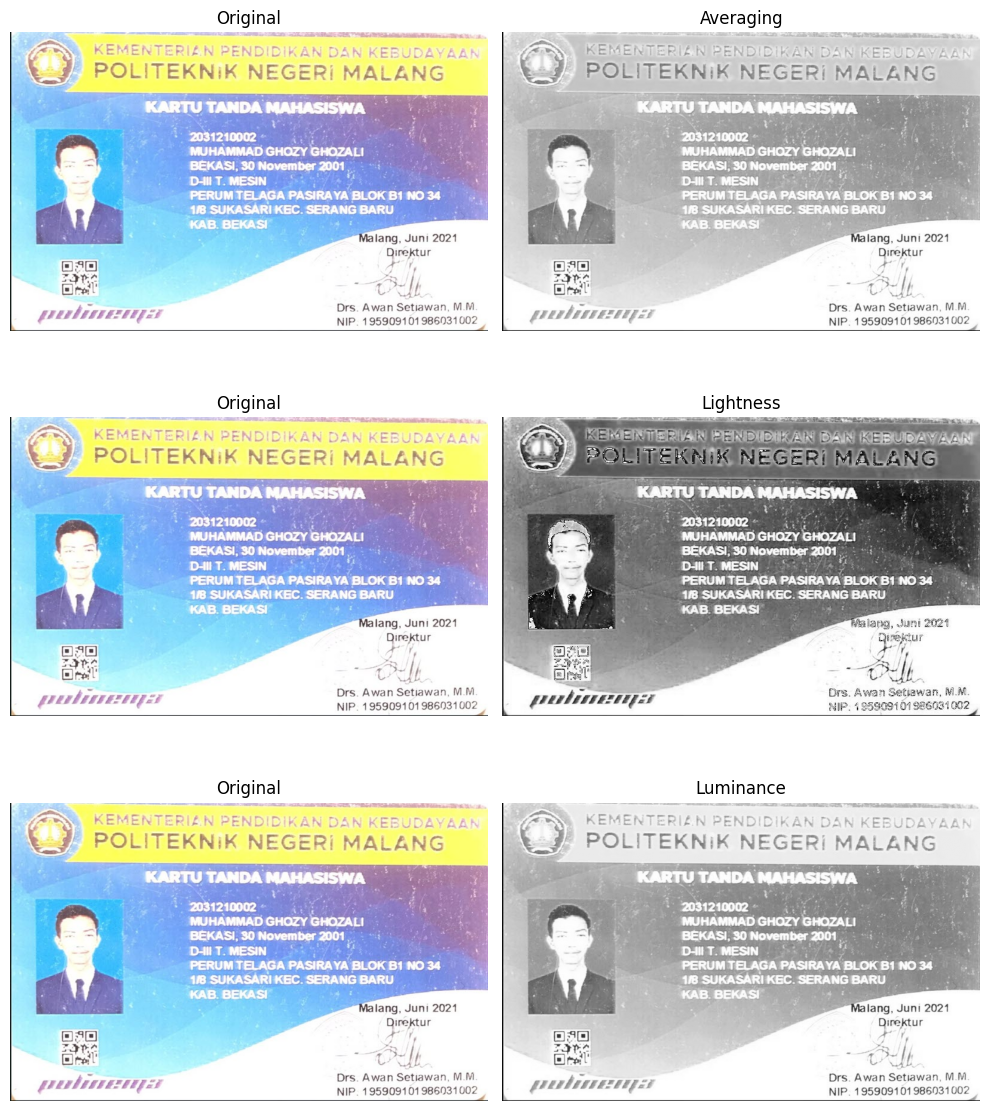

In [6]:
import matplotlib.pyplot as plt

ktm = cv2.imread('/content/drive/MyDrive/PCVK25_3F_15/image/Gambar Jobsheet 3/KTM lama.jpg')

B, G, R = cv2.split(ktm)
ktm_rgb = cv2.cvtColor(ktm, cv2.COLOR_BGR2RGB)

# Averaging
gray_avg = ((R.astype(np.float32) + G.astype(np.float32) + B.astype(np.float32)) / 3).astype(np.uint8)

# Lightness
gray_lightness = ((np.maximum(np.maximum(R,G), B)+np.minimum(np.minimum(R,G), B)) / 2).astype(np.uint8)

# Luminance
gray_luminance = (0.299 * R + 0.587 * G + 0.114 * B).astype(np.uint8)

plt.figure(figsize=(10, 12))

# Original vs Averaging
plt.subplot(3, 2, 1)
plt.imshow(ktm_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(3, 2, 2)
plt.imshow(gray_avg, cmap='gray')
plt.title("Averaging")
plt.axis("off")

# Original vs Lightness
plt.subplot(3, 2, 3)
plt.imshow(ktm_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(3, 2, 4)
plt.imshow(gray_lightness, cmap='gray')
plt.title("Lightness")
plt.axis("off")

# Original vs Luminance
plt.subplot(3, 2, 5)
plt.imshow(ktm_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(3, 2, 6)
plt.imshow(gray_luminance, cmap='gray')
plt.title("Luminance")
plt.axis("off")

plt.tight_layout()
plt.show()

5. Tampilkanlah warna tertentu pada citra, dan ubah warna lain menjadi grayscale. Misal,
tampilkan warna biru pada citra masukan dan ubah bagian lain yang tidak berwarna
biru menjadi grayscale seperti pada contoh berikut:

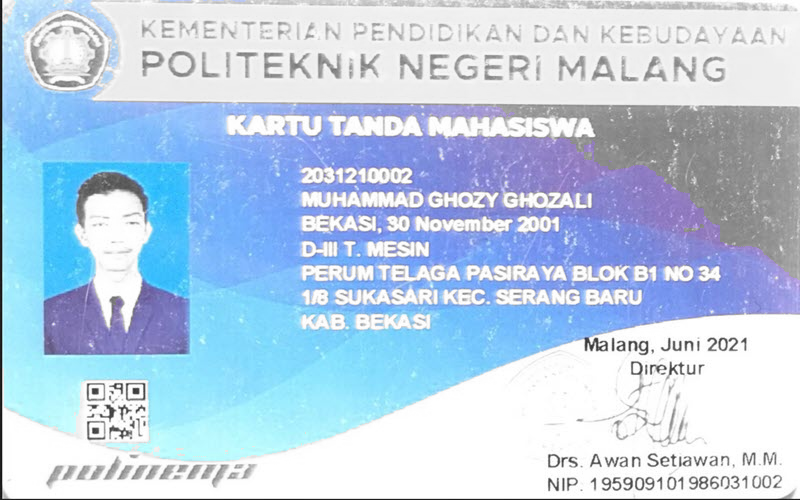

In [7]:
ktm = cv2.imread('/content/drive/MyDrive/PCVK25_3F_15/image/Gambar Jobsheet 3/KTM lama.jpg')
ktm_rgb = cv2.cvtColor(ktm, cv2.COLOR_BGR2RGB)

# Konversi ke HSV
hsv = cv2.cvtColor(ktm, cv2.COLOR_BGR2HSV)

# Rentang biru HSV
lower_blue = np.array([90, 50, 50])
upper_blue = np.array([130, 255, 255])

mask = cv2.inRange(hsv, lower_blue, upper_blue)
result = cv2.bitwise_and(ktm, ktm, mask=mask)

# Grayscale bagian lain
gray = cv2.cvtColor(ktm, cv2.COLOR_BGR2GRAY)
gray_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

final = np.where(mask[..., None] != 0, result, gray_bgr)

cv2_imshow(final)

# Praktikum D2

1. Buat Gamma Correction sesuai dengan petunjuk berikut
Percobaan ini akan meminta anda membuat Gamma Correction. Pada percobaan ini, nilai
Gamma akan diset dengan meminta masukan dari pengguna. Berikut adalah kode untuk
meminta masukan nilai dari pengguna. Lanjutkan kode tersebut dengan membuat image
dengan gamma correction sesuai rumus yang telah diberikan.

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 3


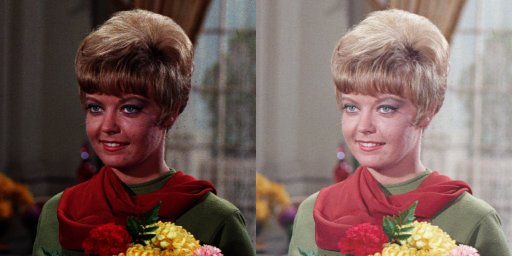

In [18]:
from google.colab.patches import cv2_imshow
import cv2 as cv
import numpy as np

print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

# Baca gambar
original = cv2.imread('/content/drive/MyDrive/PCVK25_3F_15/image/Gambar Jobsheet 3/female.tiff')

# Normalisasi [0,1]
normalized = original / 255.0

# Rumus gamma correction (pakai inverse gamma biar konsisten dengan teori pencahayaan)
inv_gamma = 1.0 / gamma
gamma_corrected = np.power(normalized, inv_gamma)

# Kembalikan ke [0,255]
gamma_corrected = np.uint8(gamma_corrected * 255)

# Tampilkan hasil
final_frame = cv2.hconcat((original, gamma_corrected))
cv2_imshow(final_frame)


2. Buat Simulasi Image Depth

Percobaan ini digunakan sebagai simulasi dari proses kuantisasi citra. Pada kuantisasi
citra, pixel dapat direpresentasikan dengan n-bit kedalaman (default menggunakan 8-bit).
Pada pixel 8-bit, warna yang memungkinkan adalah 256 warna, dari 0 (0000 0000) hingga
255(1111 1111). Pada pixel 7-bit, warna yang memungkinkan adalah 128 warna, dari 0
(000 0000) hingga 127 (111 1111). Kemungkinan warna didapat dari pangkat 2 jumlah bit.
Jika 7bit, maka jumlah warnanya adalah 2
7
 = 128, dst.

Berikut adalah kode untuk membaca citra masukan dan memberi nilai kedalaman citra,
silahkan lanjutkan kode program berikut sehingga menghasilkan keluaran seperti contoh
pada Gambar.

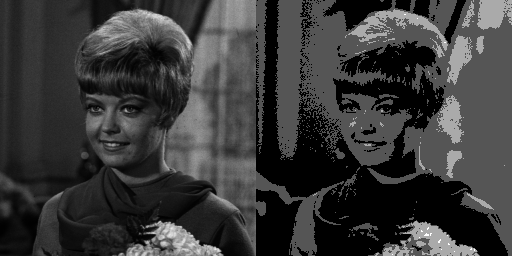

In [19]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

# menentukan bit depth
bit_depth = 2

level = 255 / (pow(2, bit_depth) - 1)

original = cv2.imread('/content/drive/MyDrive/PCVK25_3F_15/image/Gambar Jobsheet 3/female.tiff', cv2.IMREAD_GRAYSCALE)

depth_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    depth_image[y,x] = np.round(original[y,x] / level) * level

final_frame = cv2.hconcat((original, depth_image))
cv2_imshow(final_frame)


3. Buat modul Average Denoising

Buat modul average denoising sesuai dengan rumus yang telah diberikan pada sub bab
sebelumnya.
Citra asli sudah disediakan pada /images/galaxy.jpg.

100 Citra dengan Gaussian Noise sudah disediakan pada /images/noises/*.jpg

Anda dapat menggunakan code berikut untuk membaca semua image dalam satu folder ,
gunakan modul glob (import glob).

Jumlah gambar noisy tersedia: 124
Jumlah: 10 -> PSNR: 22.82 dB


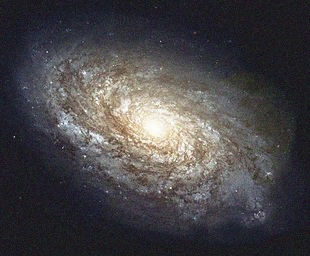

Jumlah: 20 -> PSNR: 23.03 dB


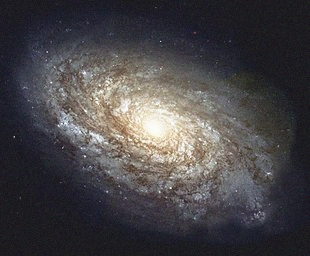

Jumlah: 40 -> PSNR: 23.35 dB


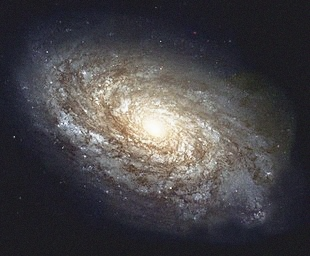

Jumlah: 80 -> PSNR: 23.28 dB


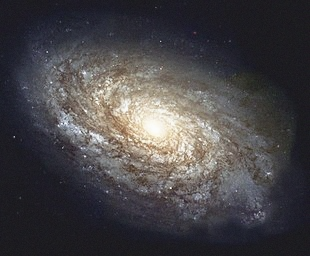

Jumlah: 100 -> PSNR: 23.27 dB


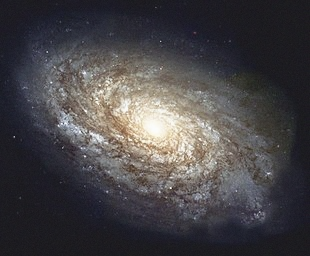

In [34]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np
import glob

# Fungsi MSE
def mse(img1, img2):
  err = np.mean((img1.astype("float")-img2.astype("float"))**2)
  return err

# Fungsi PSNR
def psnr(img1, img2):
  mse_val = mse(img1, img2)
  if mse_val == 0:
    return float("inf")
  PIXEL_MAX = 255.0
  return 10 * np.log10((PIXEL_MAX ** 2) / mse_val)

# Baca citra asli
image_original = cv2.imread('/content/drive/MyDrive/PCVK25_3F_15/image/Gambar Jobsheet 3/noises/1.jpg')

# Baca semua citra noisy
cv_img = []
for img in glob.glob('/content/drive/MyDrive/PCVK25_3F_15/image/Gambar Jobsheet 3/noises/*.jpg'):
    n = cv.imread(img)
    if n is not None:
        cv_img.append(n)

print(f"Jumlah gambar noisy tersedia: {len(cv_img)}")

jumlah_list = [10,20,40,80,100]
for jumlah in jumlah_list:
  sum_img = np.zeros_like(cv_img[0], dtype=np.float32)

  # ambil citra sesuai jumlah
  for noisy in cv_img[:jumlah]:
    sum_img += noisy.astype(np.float32)

  avg_img = np.uint8(sum_img / jumlah)

  # Hitung PSNR
  psnr_val = psnr(image_original, avg_img)

  print(f"Jumlah: {jumlah} -> PSNR: {psnr_val:.2f} dB")

  cv2_imshow(avg_img)

Dari hasil Average Denoising dan nilai dari PSNR, Jumlah citra noisy yang digunakan dalam averaging denoising dapat memperbaiki kualitas citranya. Hal ini dapat diliha dari nilai PSNR yang bertambah.

4. Buat image masking

Buat image masking untuk image berikut. Image kiri adalah image asli (images/couple.tiff),
sedangkan image paling kanan adalah hasilnya:

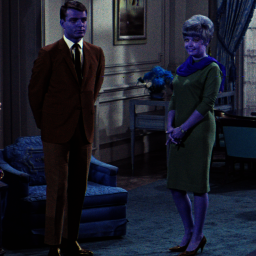

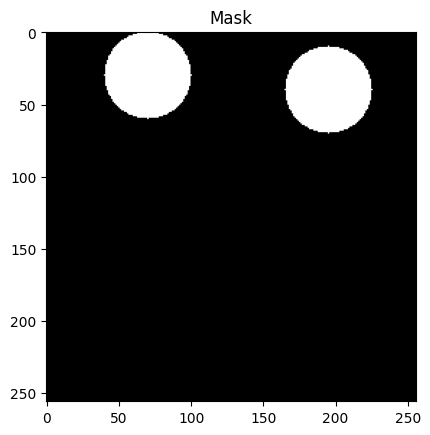

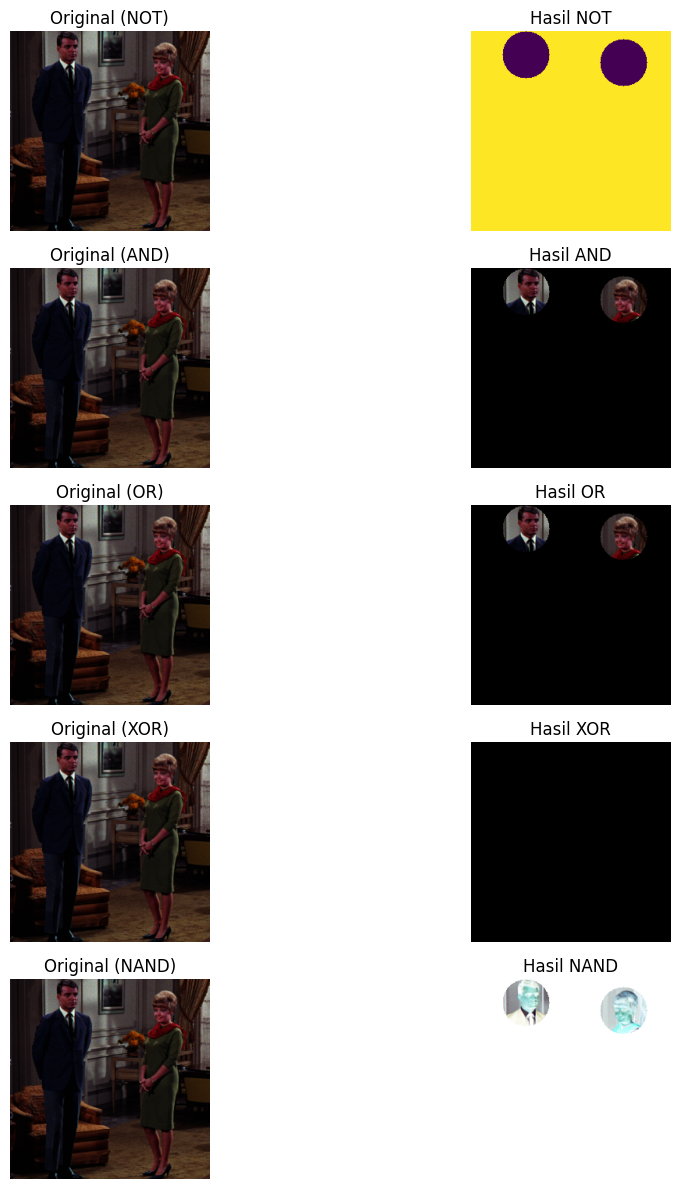

In [60]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

# ambil image couple
pict = cv2.imread('/content/drive/MyDrive/PCVK25_3F_15/image/Gambar Jobsheet 3/couple.tiff')
pict = cv2.cvtColor(pict, cv2.COLOR_BGR2RGB)

# lihat citra
cv2_imshow(pict)

# buat mask
mask = np.zeros(pict.shape[:2], dtype="uint8")

# buat dua lingkaran putih
left_circle = cv2.circle(mask, (195, 40), 30, 255, -1) # lingkaran wanita
right_circle = cv2.circle(mask, (70, 30), 30, 255, -1) # lingkaran pria

plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.show()

# NOT
not_result = cv2.bitwise_not(mask)

# AND
and_result = cv2.bitwise_and(pict, pict, mask=mask)

# OR
or_result = cv2.bitwise_or(pict, pict, mask=mask)

# XOR
xor_result = cv2.bitwise_xor(pict, pict, mask=mask)

# NAND
nand_result = cv2.bitwise_not(and_result)

# tampilkan hasil
titles = ["Original", "Mask", "NOT", "AND", "OR", "XOR", "NAND"]
images = [
    (pict, not_result,  "NOT"),
    (pict, and_result,  "AND"),
    (pict, or_result,   "OR"),
    (pict, xor_result,  "XOR"),
    (pict, nand_result, "NAND"),
]

# Plot perbandingan Ori vs Hasil
plt.figure(figsize=(12, 12))
for i, (ori, hasil, title) in enumerate(images):
    # Original
    plt.subplot(len(images), 2, 2*i+1)
    plt.imshow(ori)
    plt.title(f"Original ({title})")
    plt.axis("off")

    # Hasil
    plt.subplot(len(images), 2, 2*i+2)
    plt.imshow(hasil)
    plt.title(f"Hasil {title}")
    plt.axis("off")

plt.tight_layout()
plt.show()


**Hasil Analisis**

Image masking dapat menampilkan bagian tertentu dari suatu citra. Dari gambar ini, kita hanya ingin menampilkan gambar pria dan wanita. Cara melakukannya adalah membuat mask berbentuk lingkaran untuk menunjukkan bagian tertentu dari citra tersebut. Di image masking ini, kita bisa menggunakan operator lain. Caranya adalah menggunakan method bitwise, kemudian bisa memilih operator Berikut adalah detailnya.
1. NOT = mask dibalik sehingga citra menjadi tidak terlihat dan backround hitam yang dimunculkan,
2. AND = mask hanya menampilkan area yang putih sehingga citra menampilkan 2 wajah pasangan yang sudah dimasking,
3. OR = citra menampilkan salah satu atau 2 dua wajah pasangan,
4. XOR = mask membuat citra menjadi hitam karena hanya bagian yang beda yang muncul,
5. NAND = kebalikan AND.